In [1]:
!pip install catboost scikit-learn pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import os


from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt
import seaborn as sns

print(os.getcwd())
print(os.listdir())

/content
['.config', 'sample_data']


In [3]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles in current directory:")
print(os.listdir())

Current directory:
/content

Files in current directory:
['.config', 'sample_data']


In [5]:
import pandas as pd

train = pd.read_csv("/content/dataset_C_training.csv")
test = pd.read_csv("/content/dataset_C_testing.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (4756, 31)
Test Shape: (4749, 30)


In [6]:
train.head()

,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
0,1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Employed,"MSA, Principle City",3.0,2.0,0,4,4,2.0,construction,0
1,2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Employed,Non-MSA,0.0,0.0,0,5,2,1.0,education,1
2,3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,2,2,5.0,wholesale,0
3,4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,1,3,3,2.0,NaN,1
4,5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,3,2,2.0,wholesale,0


In [7]:
missing = train.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

,0
employment_sector,2330
health_insurance,1908
income_poverty,748
rent_or_own,329
employment_status,238
marital_status,231
education,228
chronic_med_condition,169
child_under_6_months,135
health_worker,132


In [8]:
train["covid_vaccine"].value_counts()

,count
covid_vaccine,
0,3202
1,1554


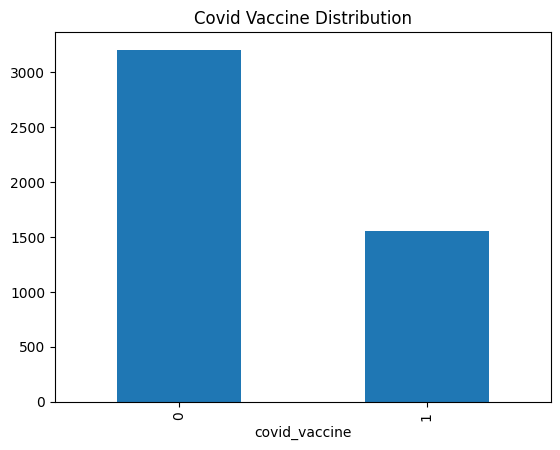

In [9]:
train["covid_vaccine"].value_counts().plot(
    kind="bar"
)

plt.title("Covid Vaccine Distribution")
plt.show()

In [10]:
for df in [train, test]:

    df["behavior_score"] = (
        df["behavioral_avoidance"].fillna(0)
        + df["behavioral_face_mask"].fillna(0)
        + df["behavioral_wash_hands"].fillna(0)
        + df["behavioral_large_gatherings"].fillna(0)
        + df["behavioral_outside_home"].fillna(0)
        + df["behavioral_touch_face"].fillna(0)
    )

    df["risk_score"] = (
        df["covid_concern"].fillna(0)
        + df["opinion_covid_risk"].fillna(0)
    )

    df["vaccine_confidence"] = (
        df["opinion_covid_vacc_effective"].fillna(0)
        - df["opinion_covid_sick_from_vacc"].fillna(0)
    )

In [11]:
TARGET = "covid_vaccine"

X = train.drop(columns=[TARGET])

y = train[TARGET]

In [12]:
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

print(cat_features)

['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'employment_sector']


In [13]:
# Find categorical columns
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

# Convert categorical columns to string
for col in cat_features:
    X[col] = X[col].fillna("Unknown").astype(str)
    test[col] = test[col].fillna("Unknown").astype(str)

print(cat_features)

['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'employment_sector']


In [14]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_valid.shape)

(3804, 33)
(952, 33)


In [15]:
model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    eval_metric="AUC",
    loss_function="Logloss",
    random_seed=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

0:	test: 0.8427572	best: 0.8427572 (0)	total: 62.3ms	remaining: 2m 4s
100:	test: 0.8601462	best: 0.8601462 (100)	total: 1.36s	remaining: 25.5s
200:	test: 0.8644351	best: 0.8644903 (198)	total: 3.62s	remaining: 32.4s
300:	test: 0.8652226	best: 0.8652226 (300)	total: 5.42s	remaining: 30.6s
400:	test: 0.8643498	best: 0.8653029 (306)	total: 6.77s	remaining: 27s
500:	test: 0.8635623	best: 0.8653029 (306)	total: 8.17s	remaining: 24.4s
600:	test: 0.8624436	best: 0.8653029 (306)	total: 9.58s	remaining: 22.3s
700:	test: 0.8618918	best: 0.8653029 (306)	total: 11s	remaining: 20.4s
800:	test: 0.8611795	best: 0.8653029 (306)	total: 12.4s	remaining: 18.6s
900:	test: 0.8609438	best: 0.8653029 (306)	total: 13.8s	remaining: 16.9s
1000:	test: 0.8602967	best: 0.8653029 (306)	total: 15.7s	remaining: 15.7s
1100:	test: 0.8595242	best: 0.8653029 (306)	total: 17.9s	remaining: 14.6s
1200:	test: 0.8590125	best: 0.8653029 (306)	total: 19.4s	remaining: 12.9s
1300:	test: 0.8592432	best: 0.8653029 (306)	total: 21.4

CatBoostClassifier(depth=6, eval_metric='AUC', iterations=2000, learning_rate=0.03, loss_function='Logloss', random_seed=42, verbose=100)

In [16]:
valid_preds = model.predict_proba(X_valid)[:,1]

auc = roc_auc_score(
    y_valid,
    valid_preds
)

print("Validation AUC:", auc)

Validation AUC: 0.8653029079362532


In [17]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.get_feature_importance()
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
25,doctor_recc_covid,14.776154
13,health_insurance,14.584021
27,opinion_covid_risk,10.326710
26,opinion_covid_vacc_effective,7.456325
29,employment_sector,5.104458
14,age_group,4.611926
31,risk_score,4.308457
15,education,3.997135
2,covid_knowledge,3.127668
12,health_worker,3.044331


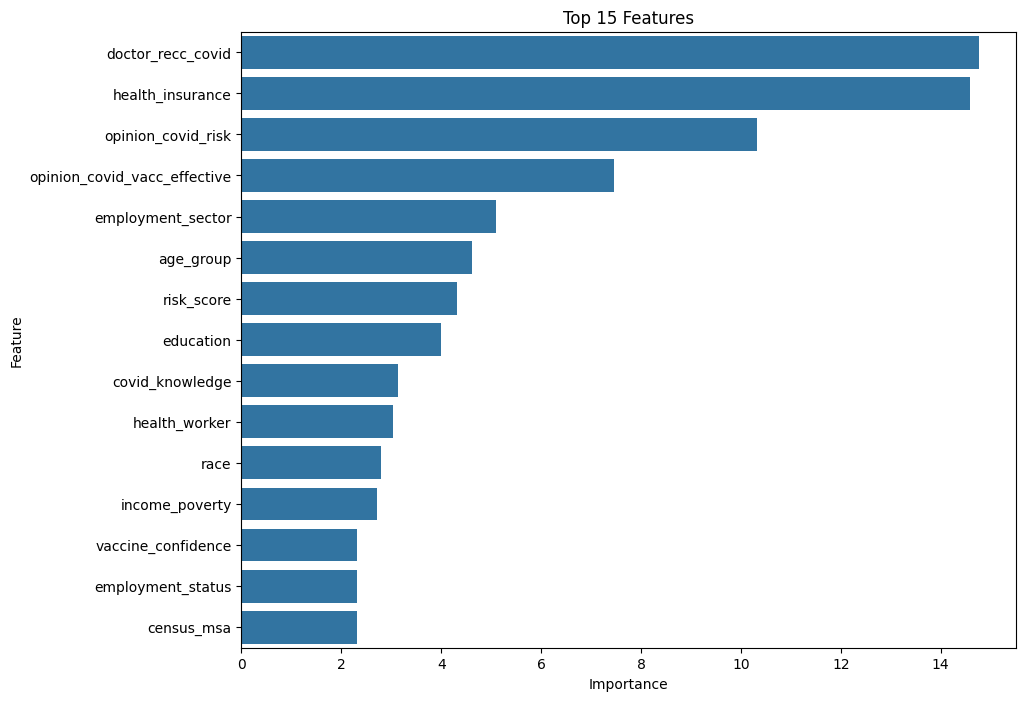

In [18]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features")
plt.show()

In [19]:
final_model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    eval_metric="AUC",
    random_seed=42,
    verbose=100
)

final_model.fit(
    X,
    y,
    cat_features=cat_features
)

0:	total: 15.4ms	remaining: 30.7s
100:	total: 1.43s	remaining: 26.9s
200:	total: 2.88s	remaining: 25.8s
300:	total: 4.38s	remaining: 24.7s
400:	total: 6.87s	remaining: 27.4s
500:	total: 8.58s	remaining: 25.7s
600:	total: 10.1s	remaining: 23.5s
700:	total: 11.6s	remaining: 21.5s
800:	total: 13.2s	remaining: 19.7s
900:	total: 14.8s	remaining: 18s
1000:	total: 16.3s	remaining: 16.3s
1100:	total: 18.4s	remaining: 15s
1200:	total: 20.6s	remaining: 13.7s
1300:	total: 22.2s	remaining: 11.9s
1400:	total: 23.7s	remaining: 10.2s
1500:	total: 25.3s	remaining: 8.42s
1600:	total: 26.9s	remaining: 6.7s
1700:	total: 28.5s	remaining: 5s
1800:	total: 30.1s	remaining: 3.33s
1900:	total: 32.8s	remaining: 1.71s
1999:	total: 34.4s	remaining: 0us


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=2000, learning_rate=0.03, random_seed=42, verbose=100)

In [20]:
test_preds = final_model.predict_proba(test)[:,1]

In [21]:
CatBoostValues = pd.DataFrame({
    "respondent_id": test["respondent_id"],
    "covid_vaccine": test_preds
})

CatBoostValues.head()

,respondent_id,covid_vaccine
0,4757,0.173276
1,4758,0.068049
2,4759,0.229154
3,4760,0.201100
4,4761,0.013349


In [22]:
CatBoostValues.to_csv(
    "CatBoostValues.csv",
    index=False
)

print("CatBoostValues Saved")

CatBoostValues Saved


In [23]:
pd.read_csv("CatBoostValues.csv").head()

,respondent_id,covid_vaccine
0,4757,0.173276
1,4758,0.068049
2,4759,0.229154
3,4760,0.201100
4,4761,0.013349


In [24]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

valid_preds_proba = model.predict_proba(X_valid)[:, 1]

valid_preds_labels = (valid_preds_proba >= 0.5).astype(int)

accuracy = accuracy_score(y_valid, valid_preds_labels)
precision = precision_score(y_valid, valid_preds_labels)
f1 = f1_score(y_valid, valid_preds_labels)
roc_auc = roc_auc_score(y_valid, valid_preds_proba)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Accuracy:  0.8130
Precision: 0.7608
F1 Score:  0.6855
ROC-AUC:   0.8653


In [27]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_model.get_feature_importance()
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(15))

feature_importance.to_csv("/content/outputs/catboost_feature_importance.csv", index=False)

,Feature,Importance
0,respondent_id,9.069779
13,health_insurance,7.817416
25,doctor_recc_covid,7.190417
14,age_group,6.942453
29,employment_sector,6.295936
27,opinion_covid_risk,6.282728
26,opinion_covid_vacc_effective,4.847627
15,education,4.826702
18,income_poverty,4.193365
31,risk_score,3.967288


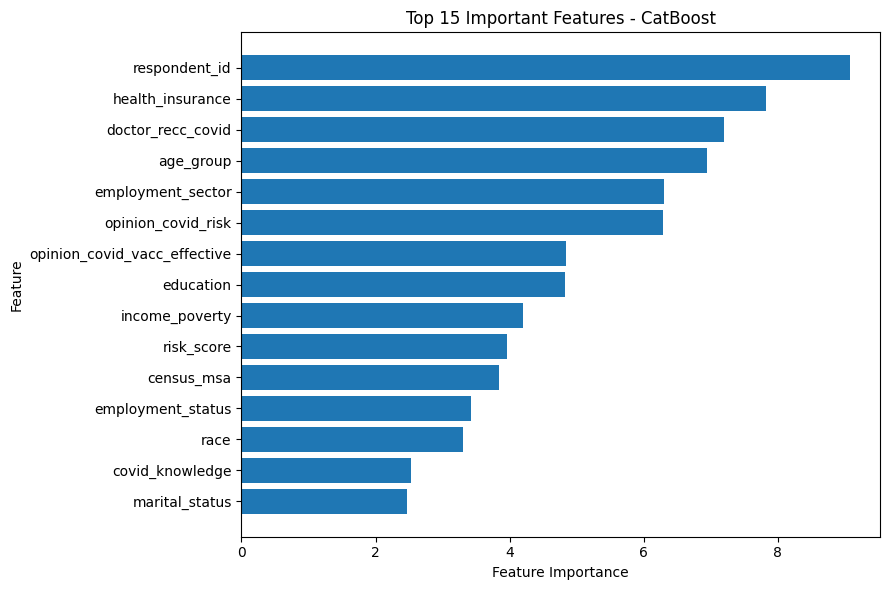

In [29]:
top_features = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(9, 6))
plt.barh(top_features["Feature"], top_features["Importance"])

plt.title("Top 15 Important Features - CatBoost")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig("/content/outputs/catboost_feature_importance.png", bbox_inches="tight")
plt.show()

In [31]:
from catboost import Pool

valid_pool = Pool(
    X_valid,
    label=y_valid,
    cat_features=cat_features
)

In [32]:
valid_pool = Pool(
    X_valid,
    label=y_valid,
    cat_features=cat_features
)

shap_values = final_model.get_feature_importance(
    valid_pool,
    type="ShapValues"
)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (952, 34)


In [33]:
shap_values_only = shap_values[:, :-1]
expected_value = shap_values[:, -1].mean()

print("SHAP values only shape:", shap_values_only.shape)
print("Expected value:", expected_value)

SHAP values only shape: (952, 33)
Expected value: -1.2431023730039066


In [35]:
import shap

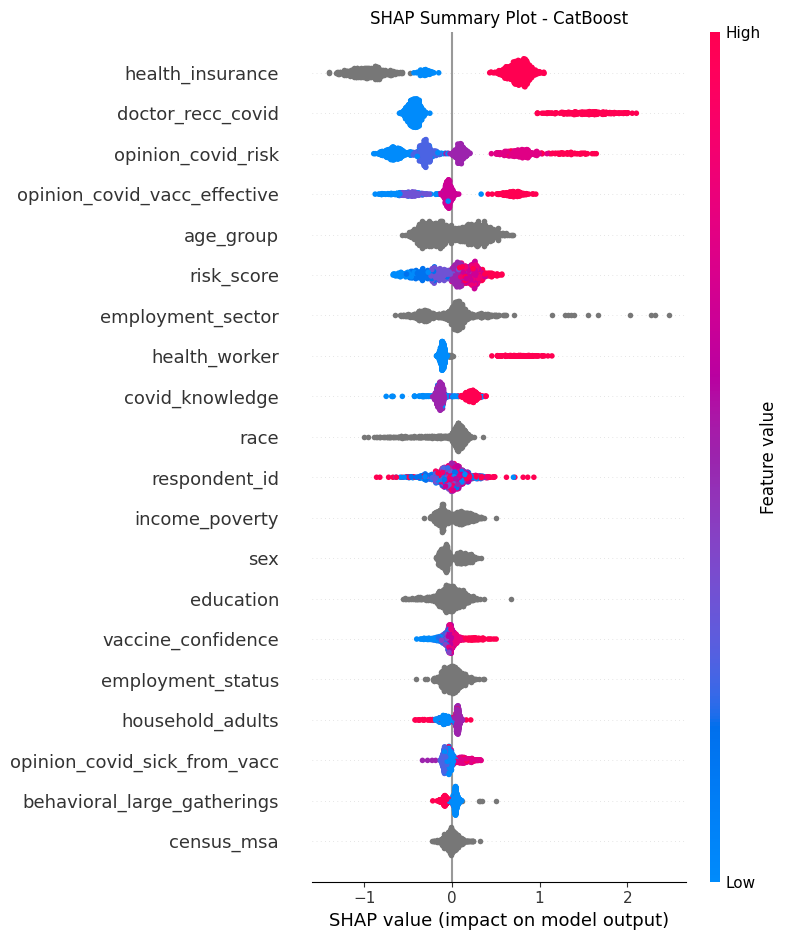

In [37]:
shap.summary_plot(
    shap_values_only,
    X_valid,
    show=False
)

plt.title("SHAP Summary Plot - CatBoost")
plt.tight_layout()
plt.savefig("/content/outputs/catboost_shap_summary.png", bbox_inches="tight")
plt.show()

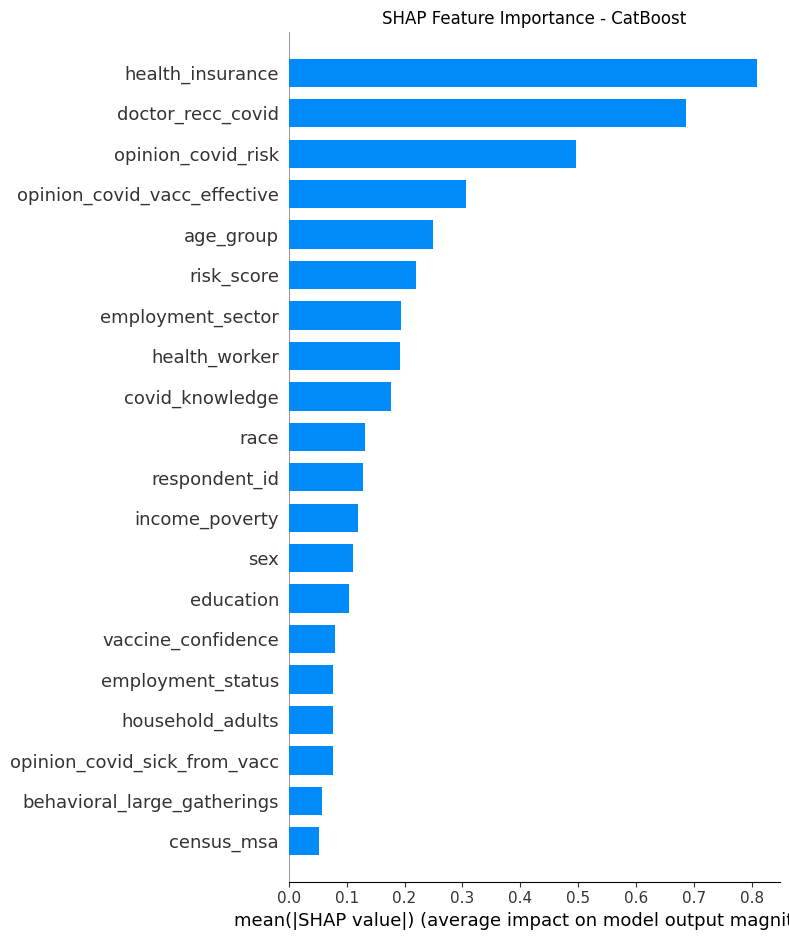

In [39]:
shap.summary_plot(
    shap_values_only,
    X_valid,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance - CatBoost")
plt.tight_layout()
plt.savefig("/content/outputs/catboost_shap_bar.png", bbox_inches="tight")
plt.show()

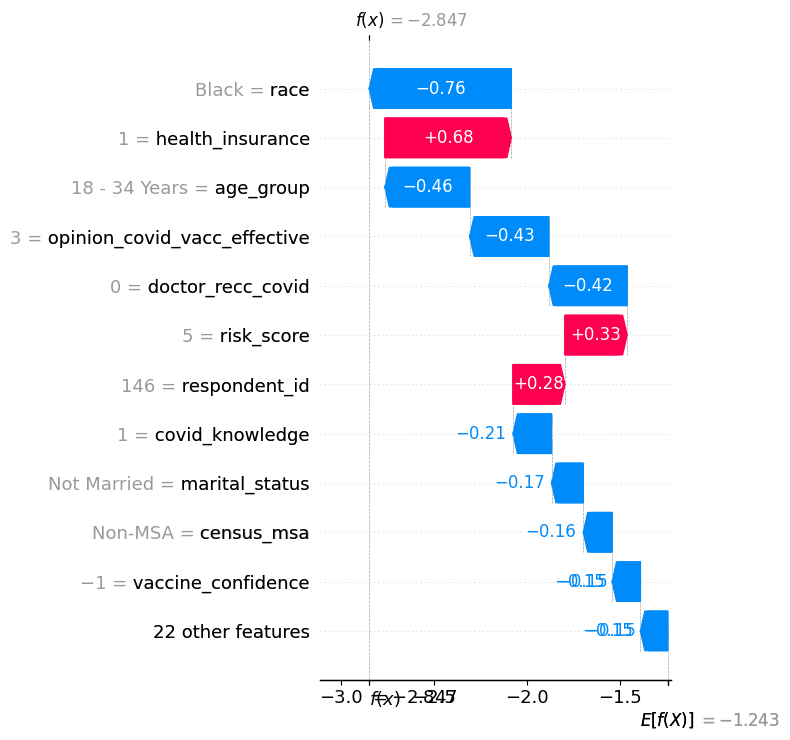

In [41]:
instance_idx = 0

explanation = shap.Explanation(
    values=shap_values_only[instance_idx],
    base_values=expected_value,
    data=X_valid.iloc[instance_idx],
    feature_names=X_valid.columns
)

shap.plots.waterfall(explanation, max_display=12, show=False)

plt.tight_layout()
plt.savefig("/content/outputs/catboost_shap_waterfall_instance_0.png", bbox_inches="tight")
plt.show()

In [42]:
top_5_features = feature_importance.head(5)["Feature"].tolist()
top_5_features

['respondent_id',
 'health_insurance',
 'doctor_recc_covid',
 'age_group',
 'employment_sector']

In [43]:
from sklearn.inspection import PartialDependenceDisplay

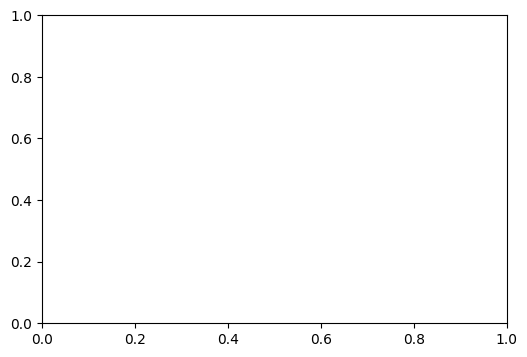

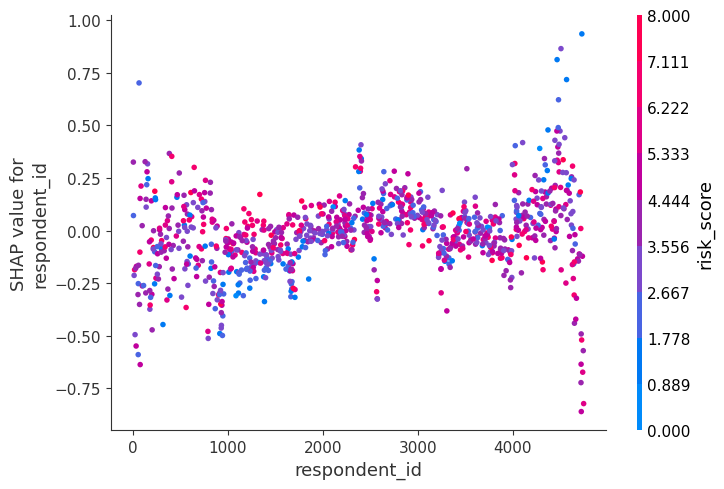

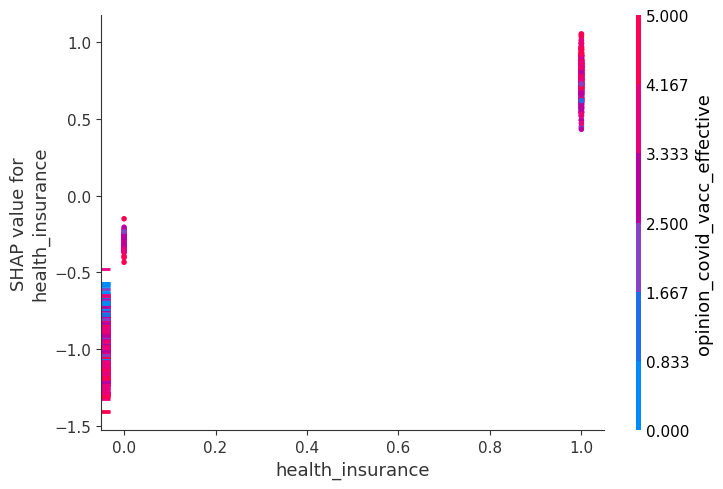

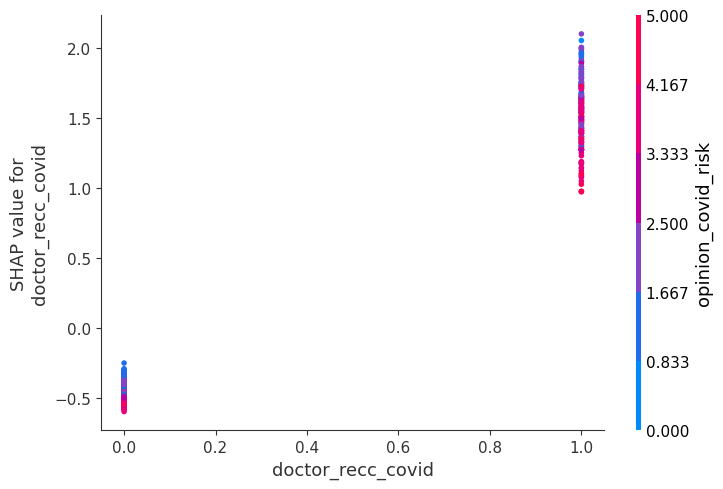

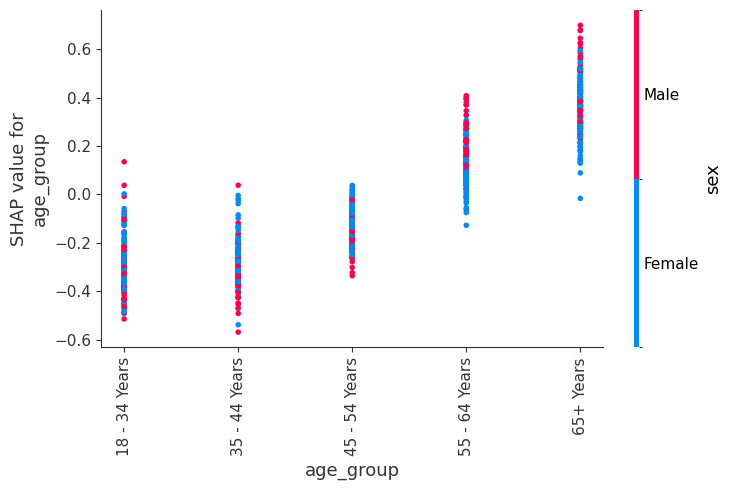

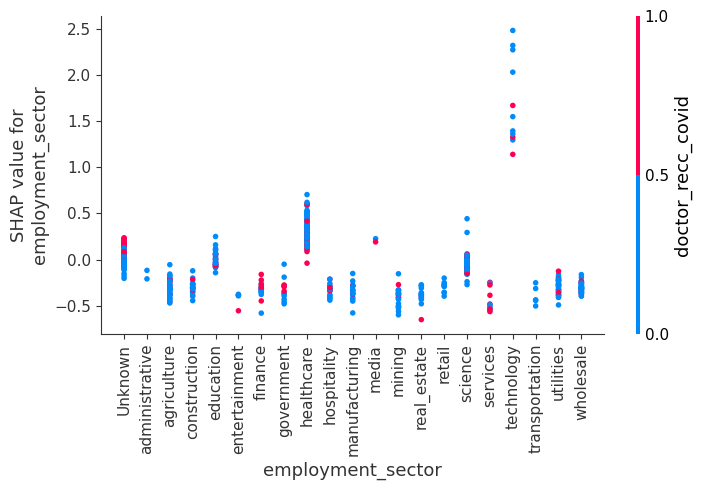

In [49]:
import shap

for feature in top_5_features:
    shap.dependence_plot(
        feature,
        shap_values[:, :-1],
        X_valid,
        show=False
    )

    plt.tight_layout()
    plt.savefig(f"shap_dependence_{feature}.png")
    plt.show()

In [50]:
print(type(final_model))
print(final_model)

<class 'catboost.core.CatBoostClassifier'>
CatBoostClassifier(depth=6, eval_metric='AUC', iterations=2000, learning_rate=0.03, random_seed=42, verbose=100)


In [51]:
print(final_model.classes_)
print(final_model.predict_proba(X_valid[:5]).shape)

[0 1]
(5, 2)


In [54]:
X_test_cat = test[X_train.columns]

In [55]:
test_probs = final_model.predict_proba(X_test_cat)[:, 1]

CatBoostValues_XAI = pd.DataFrame({
    "respondent_id": test["respondent_id"],
    "covid_vaccine": test_probs
})

CatBoostValues_XAI.to_csv("/content/outputs/CatBoostValues_XAI_Final.csv", index=False)

CatBoostValues_XAI.head()

,respondent_id,covid_vaccine
0,4757,0.173276
1,4758,0.068049
2,4759,0.229154
3,4760,0.201100
4,4761,0.013349
